# Imports

In [2]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: c:\Users\Navya\Desktop\Quant Projects\derivatives-risk-engine


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from src.gbm import GBMSimulator
from src.monte_carlo import MonteCarloPricer
from src.black_scholes import BlackScholes
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load SPY Data + Set Options Parameters

In [4]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
r = 0.03
q = 0.0

K = S * 1.02  # 2% OTM call
T = 0.25      # 3 months

print(f"{ticker} S:", S)
print(f"Estimated annualized vol:", sigma_hat)
print(f"Option: K={K}, T={T}, r={r}, q={q}")

SPY S: 754.8300170898438
Estimated annualized vol: 0.17117609741316844
Option: K=769.9266174316407, T=0.25, r=0.03, q=0.0


# Black-Scholes Reference Price

In [5]:
bs = BlackScholes(S, K, T, r, sigma_hat, q=q)
bs_price = bs.call_price()
print(f"Black-Scholes call price: {bs_price:.4f}")

Black-Scholes call price: 21.5204


# Configure GBM Simulator and MC Pricer

In [6]:
mu_hat = float(returns.mean() * 252)
dt = 1 / 252

sim = GBMSimulator(S0=S, mu=r-q, sigma=sigma_hat, T=T, dt=dt, n_paths=10000)
mc = MonteCarloPricer(sim, r=r, q=q)

# MC Price vs Number of Simulations

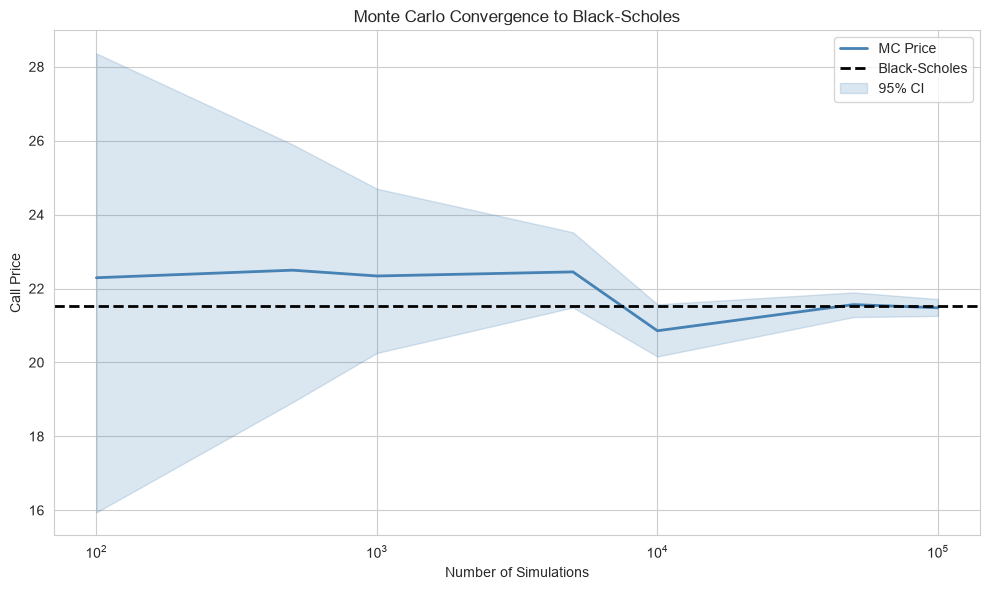

MC error at 100,000 sims: 0.192%


In [7]:
n_sims = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = []
mc_ci_low = []
mc_ci_high = []

for n in n_sims:
    sim.n_paths = n
    sim.paths = None
    price = mc.price_european_call(K)
    lo, hi = mc.confidence_interval(K, option_type="call", n_bootstrap=500)
    mc_prices.append(price)
    mc_ci_low.append(lo)
    mc_ci_high.append(hi)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_sims, mc_prices, color="steelblue", lw=2, label="MC Price")
ax.axhline(bs_price, color="black", lw=2, linestyle="--", label="Black-Scholes")
ax.fill_between(n_sims, mc_ci_low, mc_ci_high, color="steelblue", alpha=0.2, label="95% CI")
ax.set_xscale("log")
ax.set_xlabel("Number of Simulations")
ax.set_ylabel("Call Price")
ax.set_title("Monte Carlo Convergence to Black-Scholes")
ax.legend()
plt.tight_layout()
plt.show()

error_pct = abs(mc_prices[-1] - bs_price) / bs_price * 100
print(f"MC error at 100,000 sims: {error_pct:.3f}%")

# European Call and Put Prices

In [8]:
sim.n_paths = 10000
sim.paths = None

call_mc = mc.price_european_call(K)
put_mc = mc.price_european_put(K)

bs_call = bs.call_price()
bs_put = bs.put_price()

print(f"European Call: MC={call_mc:.4f}, BS={bs_call:.4f}, error={abs(call_mc-bs_call)/bs_call*100:.3f}%")
print(f"European Put:  MC={put_mc:.4f}, BS={bs_put:.4f}, error={abs(put_mc-bs_put)/bs_put*100:.3f}%")

European Call: MC=21.3354, BS=21.5204, error=0.860%
European Put:  MC=30.5058, BS=30.8641, error=1.161%


# Asian Call Pricing

In [9]:
K_asian = S * 1.02
asian_price = mc.price_asian_call(K_asian)
asian_bs_approx = bs.call_price()  # vanilla reference

print(f"Asian Call (K={K_asian:.2f}): MC price = {asian_price:.4f}")
print(f"Vanilla Call (same K): MC price = {call_mc:.4f}")
print(f"Asian is cheaper than vanilla: {asian_price < call_mc}")

Asian Call (K=769.93): MC price = 9.6163
Vanilla Call (same K): MC price = 21.3354
Asian is cheaper than vanilla: True


# Barrier Call Pricing

In [10]:
K_barrier = S * 1.02
barrier = S * 1.10  # 10% above current price

barrier_knock_out = mc.price_barrier_call(K_barrier, barrier, barrier_type="knock_out")
barrier_knock_in = mc.price_barrier_call(K_barrier, barrier, barrier_type="knock_in")
vanilla = call_mc

print(f"Barrier (knock-out) Call: {barrier_knock_out:.4f}")
print(f"Barrier (knock-in) Call:  {barrier_knock_in:.4f}")
print(f"Vanilla Call:             {vanilla:.4f}")
print(f"Knock-out < Vanilla: {barrier_knock_out < vanilla}")

Barrier (knock-out) Call: 4.1960
Barrier (knock-in) Call:  17.1394
Vanilla Call:             21.3354
Knock-out < Vanilla: True


# Barrier Price vs Barrier Level

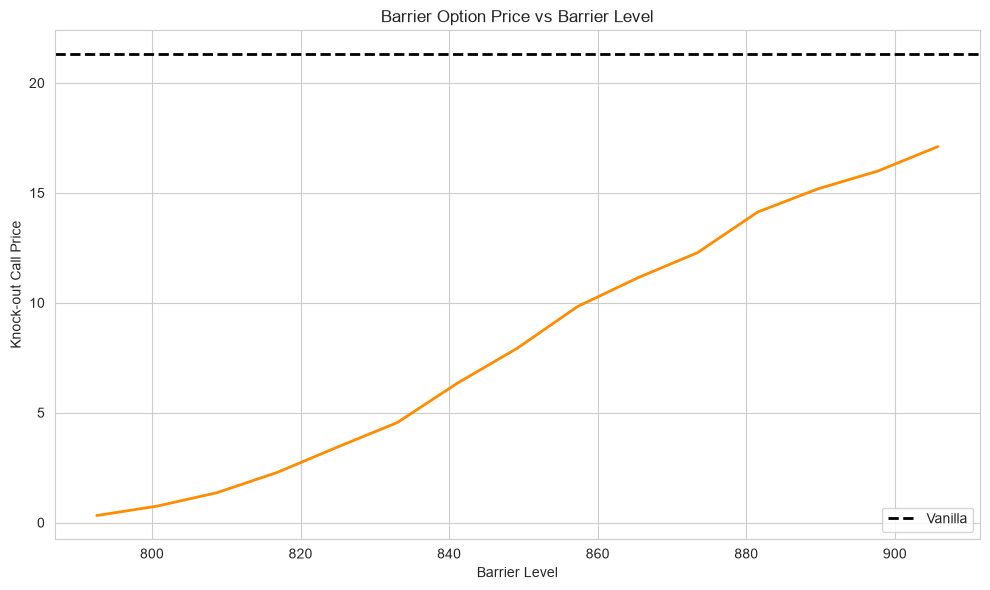

As barrier approaches spot, price → 0: True


In [11]:
barrier_levels = np.linspace(S * 1.05, S * 1.20, 15)
barrier_prices = []

for b in barrier_levels:
    sim.n_paths = 10000
    sim.paths = None
    p = mc.price_barrier_call(K_barrier, b, barrier_type="knock_out")
    barrier_prices.append(p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(barrier_levels, barrier_prices, color="darkorange", lw=2)
ax.axhline(vanilla, color="black", lw=2, linestyle="--", label="Vanilla")
ax.set_xlabel("Barrier Level")
ax.set_ylabel("Knock-out Call Price")
ax.set_title("Barrier Option Price vs Barrier Level")
ax.legend()
plt.tight_layout()
plt.show()

print(f"As barrier approaches spot, price → 0: {barrier_prices[0] < vanilla}")